In [1]:
import copy as cp
import numpy as np
np.float = np.float_
np.bool = np.bool_
np.object = np.object_
np.int = np.int_
import matplotlib as mt
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pyemma.plots as mplt
import pyemma
import pyemma.msm as msm
import pyemma.coordinates as coor
from tqdm import tqdm
import scipy as sc
import scipy.stats as sct
import scipy.optimize as sct
import sklearn as skl
import pickle as pkl
import sys
import MDAnalysis as mda
sys.path.append('../0_python_modules')
import msm_analysis as ana

/home/jayakrishnak/softwares/anaconda/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### data

In [2]:
trajs = np.loadtxt('../0_trjs/trj_list', dtype=str)

In [3]:
trajs.shape

(108,)

In [4]:
angle = np.loadtxt('../../5_angles/bound_.xvg', comments=['@','#'])[:,1].mean()
angle

78.48655514027803

In [5]:
data = [
    np.column_stack(([
        np.loadtxt(f'0_data/mindist_{i}.xvg', comments=['@','#'])[:,1],
        np.loadtxt(f'0_data/cog_{i}.xvg', comments=['@','#'])[:,1],
        np.loadtxt(f'0_data/rms_{i}.xvg', comments=['@','#'])[:,1],
        np.abs(np.loadtxt(f'0_data/angle_{i}.xvg', comments=['@','#'])[:,1]-angle)
    ]))
for i in range(len(trajs))]

In [6]:
np.concatenate((data)).shape

(3851302, 4)

### tica

In [7]:
tdata = coor.tica(data, lag=2000, dim=2).get_output()

calculate covariances:   0%|                                                                                  …

getting output of TICA:   0%|                                                                                 …

(<Figure size 432x288 with 2 Axes>, <AxesSubplot:>)

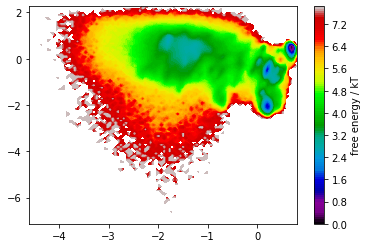

In [11]:
mplt.plot_free_energy(*np.concatenate((tdata)).T, kT=0.6)

In [9]:
np.savez('saved_msm1/tdata.npz', *tdata)

In [7]:
tdata = np.load('saved_msm1/tdata.npz')
tdata = [tdata[i] for i in list(tdata)]

### clustering

In [35]:
nclus = 200
centers = coor.cluster_kmeans(tdata, k=nclus, max_iter=5000, n_jobs=24, tolerance=1e-5)
dtrj = centers.dtrajs
centers = centers.cluster_centers_
np.savez(f'saved_msm1/dtrj_200.npz', *dtrj)
np.save('saved_msm1/centers.npy', centers)
print(np.unique(np.concatenate((dtrj))).shape)

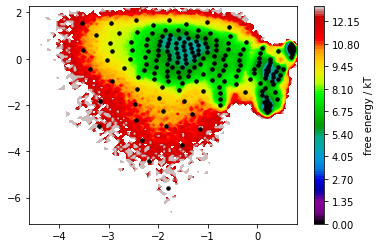

In [33]:
mplt.plot_free_energy(*np.concatenate((tdata)).T)
plt.scatter(*centers.T, s=12, c='black')
plt.show()

In [8]:
dtrj = np.load('saved_msm1/dtrj_200.npz')
dtrj = [dtrj[i] for i in list(dtrj)]

#### bp_cog

In [32]:
analyze = ana.analyze_msm_clusters(dtrj)
analyze.take_data([i[:,1] for i in data])
means, stds, probs = analyze.get_mean()

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:10<00:00, 10.78it/s]


<BarContainer object of 200 artists>

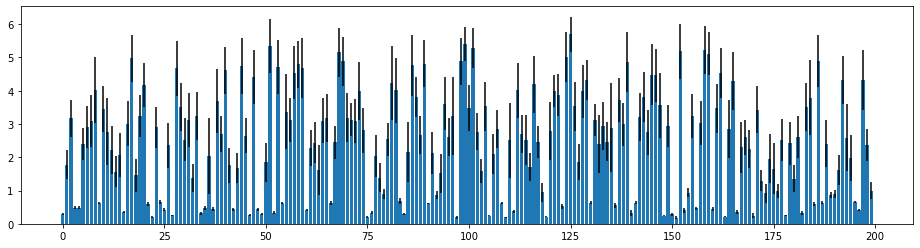

In [37]:
fig,ax=plt.subplots(1, figsize=(16,4))
ax.bar(range(nclus), means, yerr=stds)


##### small enough error bars at the lower values

### ITS

In [46]:
its = msm.its(dtrj, lags=5000, nits=10, n_jobs=24)

estimating MaximumLikelihoodMSM:   0%|                                                                        …

In [49]:
pkl.dump(its, open('saved_msm1/its.pkl', 'wb'))

In [9]:
its = pkl.load(open('saved_msm1/its.pkl', 'rb'))

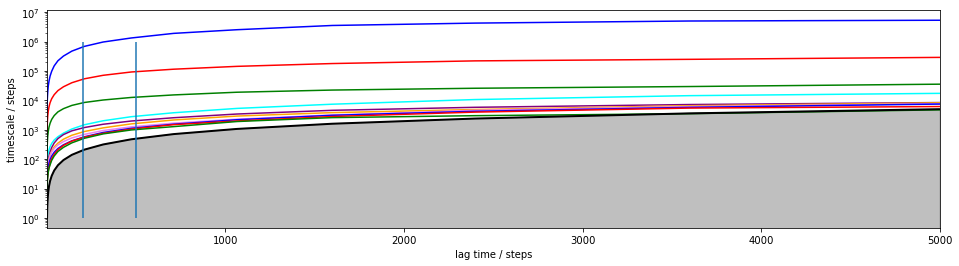

In [45]:
fig,ax=plt.subplots(1, figsize=(16,4))
mplt.plot_implied_timescales(its, ax=ax)
plt.vlines([200, 500], 1,1e6)
plt.show()

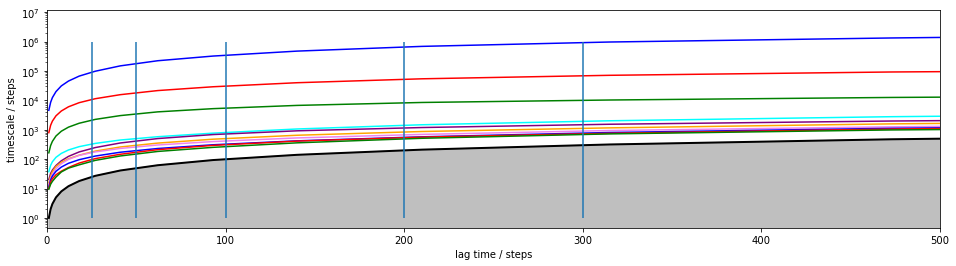

In [8]:
fig,ax=plt.subplots(1, figsize=(16,4))
mplt.plot_implied_timescales(its, ax=ax)
plt.vlines([25, 50, 100, 200, 300], 1,1e6)
plt.xlim(0,500)
plt.show()

### MSM

In [10]:
lags = np.array([0.2, 0.5, 1, 2, 3 , 5, 10, 15, 20, 50])*100 #ns : *100 steps
states = [2, 3, 4, 5, 6]

In [11]:
models = [
    msm.estimate_markov_model(dtrj, lag=lag)
for lag in lags]

In [12]:
colors = ['salmon', 'dodgerblue', 'forestgreen', 'sienna', 'blueviolet', 'olive']
colors = [
    mt.colors.ListedColormap(colors[:i])
for i in states]

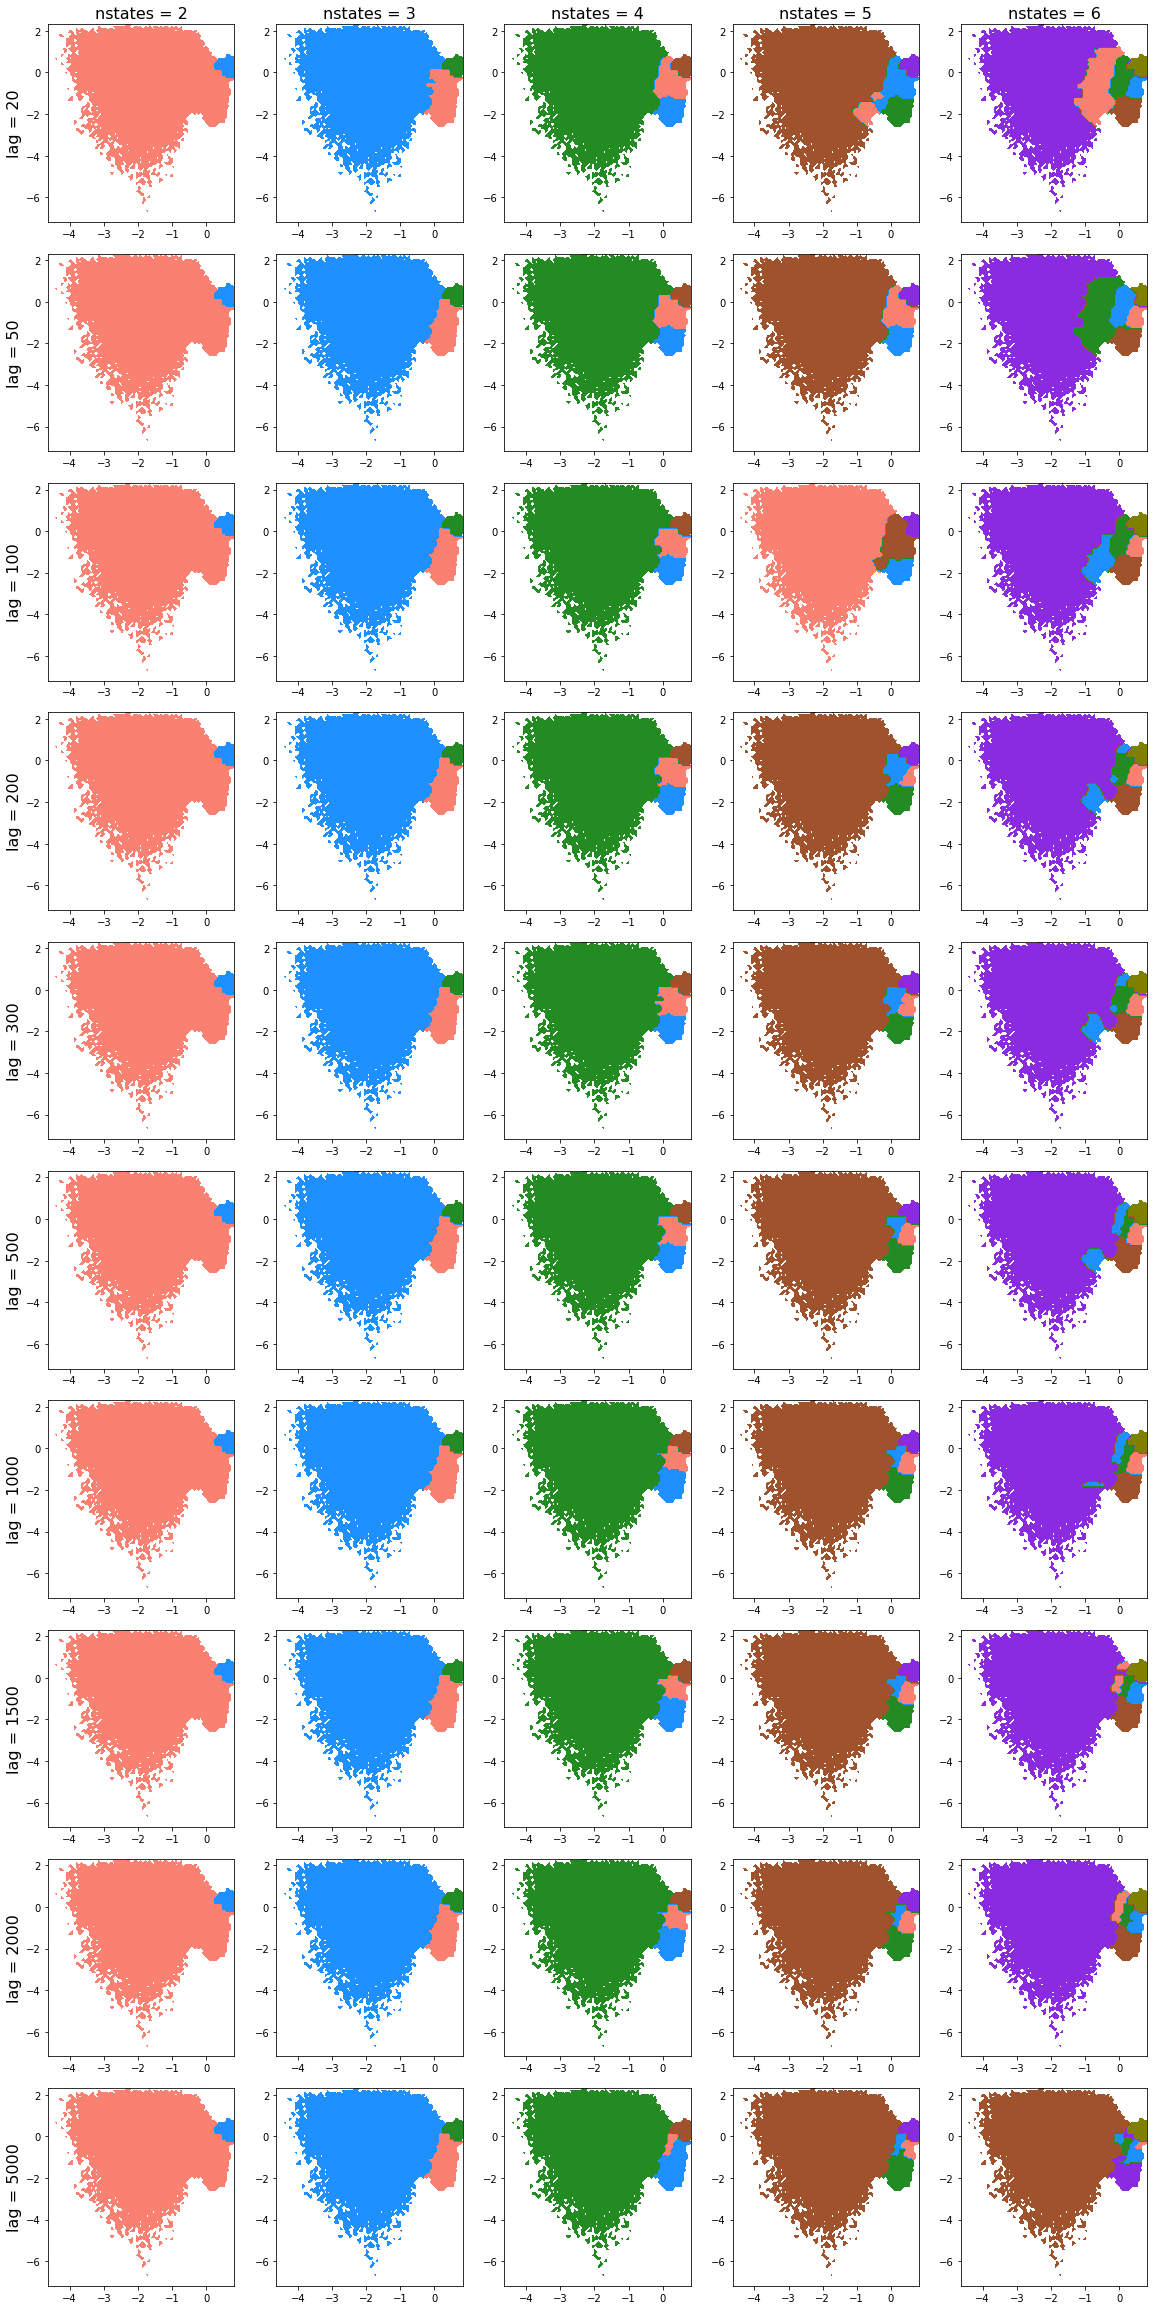

In [15]:
fig,ax=plt.subplots(len(lags), len(states), figsize=(16, (16/len(states))*len(lags) ))
plt.tight_layout()
#
for a,l in enumerate(lags):
    for b,s in enumerate(states):
        model = models[a]
        model.pcca(s)
        mplt.plot_state_map(np.concatenate((tdata))[:,0], np.concatenate((tdata))[:,1], 
                   model.metastable_assignments[np.concatenate((model.dtrajs_active))], 
                   cbar=False, cmap=colors[b], ax=ax[a,b])
        #
        if a==0:
            ax[a,b].set_title(f'nstates = {b+2}', fontsize=16)
    ax[a,0].set_ylabel(f'lag = {int(l)}', fontsize=16)
#
plt.savefig('saved_msm1/all_state_maps.pdf')
plt.show()

### for pcca = 3

In [16]:
pops = []
mfpts = []
transitions = []
for a,model in enumerate(models):
    model.pcca(3)
    mdtrj = [model.metastable_assignments[i] for i in model.dtrajs_active]
    model = msm.estimate_markov_model(mdtrj, lag=lags[a])
    #
    analyze = ana.analyze_msm_clusters(mdtrj)
    analyze.take_data([i[:,1] for i in data])
    means, _, _ = analyze.get_mean()
    
    indices = means.argsort()[::-1]
    #
    mfpts.append([
        model.mfpt(indices[0], indices[1])*10*lags[a]/1e6,
        model.mfpt(indices[1], indices[2])*10*lags[a]/1e6,
        model.mfpt(indices[0], indices[2])*10*lags[a]/1e6
    ])
    #
    pops.append(model.pi[indices])
    #
    tmt = model.count_matrix_active
    transitions.append([tmt[i][indices] for i in indices])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:09<00:00, 11.34it/s]


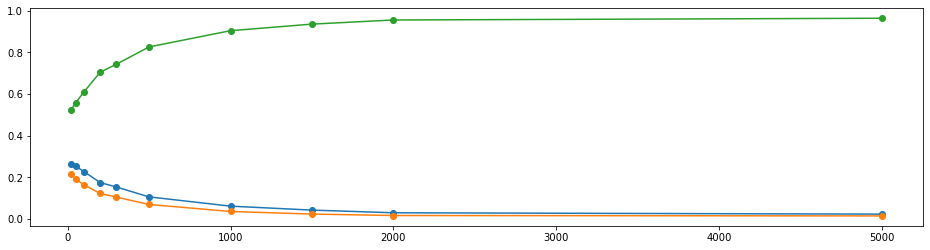

In [19]:
fig,ax=plt.subplots(1, figsize=(16,4))
for i in np.array(pops).T:
    ax.plot(lags,i, '-o')
plt.show()

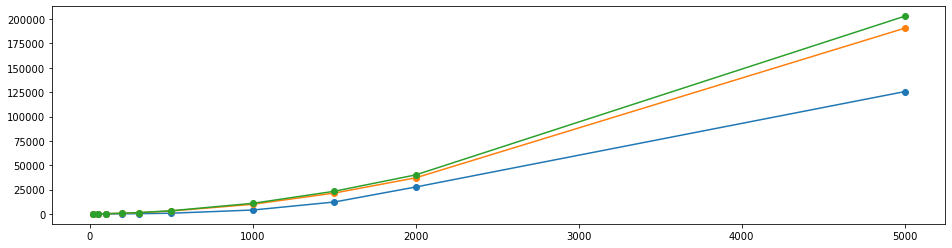

In [21]:
fig,ax=plt.subplots(1, figsize=(16,4))
for i in np.array(mfpts).T:
    ax.plot(lags,i, '-o')
plt.show()

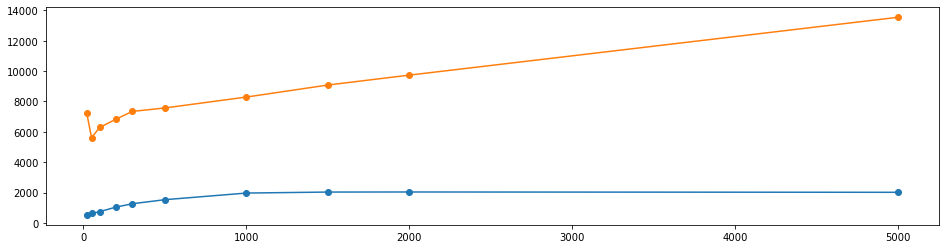

In [43]:
fig,ax=plt.subplots(1, figsize=(16,4))
ax.plot(
    lags, np.array(transitions)[:,1,2], '-o'
       )
ax.plot(
    lags, np.array(transitions)[:,0,1], '-o'
       )
plt.show()

In [44]:
mfpts[0]

[0.6980598730760323, 13.728755954759198, 14.204055862004664]

In [45]:
transitions[0]

[array([1.058002e+06, 7.267000e+03, 6.300000e+01]),
 array([7.61400e+03, 9.18466e+05, 5.27000e+02]),
 array([4.300000e+01, 4.510000e+02, 1.856709e+06])]

### final model - lag=20 (same as before), pcca=3

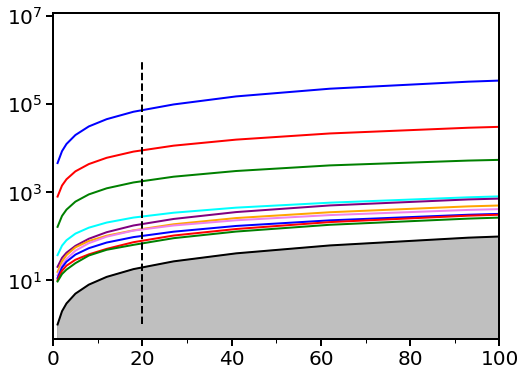

In [10]:
fig,ax=plt.subplots(1, figsize=(8,6))
mplt.plot_implied_timescales(its, ax=ax, lw=2)
ax.set_xlim(0,100)
ax.vlines(20, 1,1e6, linestyle='--', color='black', lw=2)
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines[:].set_linewidth(2)
ax.tick_params(labelsize=20, length=7, width=2)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(which='minor', length=4, width=1)
plt.savefig('saved_msm1/its.pdf')
plt.show()

In [12]:
model = msm.estimate_markov_model(dtrj, lag=20)
model.pcca(3)

PCCA(P=array([[1.23804e-01, 0.00000e+00, ..., 0.00000e+00, 0.00000e+00],
       [0.00000e+00, 2.45799e-01, ..., 5.07860e-04, 0.00000e+00],
       ...,
       [0.00000e+00, 2.24608e-04, ..., 1.98195e-01, 0.00000e+00],
       [0.00000e+00, 0.00000e+00, ..., 0.00000e+00, 3.58996e-01]]),
   m=3)

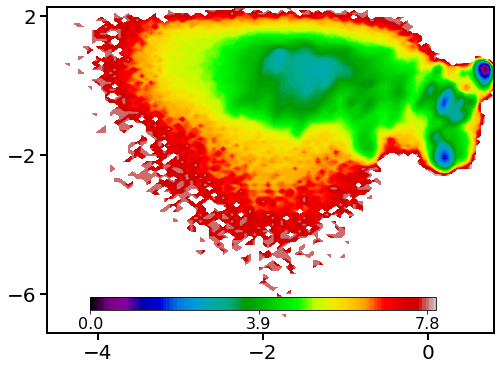

In [17]:
fig,ax = plt.subplots(1, figsize=(8,6))
cax = fig.add_axes([0.2,0.18,0.6,0.03])
mplt.plot_free_energy(*np.concatenate((tdata)).T, 
                      weights=np.concatenate((model.trajectory_weights())),
                     ax=ax, kT=0.6, cax=cax, cbar_orientation='horizontal', cbar_label=None)
cax.axes.set_xticks([0,3.9,7.8])
cax.tick_params(labelsize=16)
ax.spines[:].set_linewidth(2)
ax.set_xticks([-4,-2,0])
ax.set_yticks([-6,-2,2])
ax.tick_params(labelsize=20, length=7, width=2)
plt.savefig('saved_msm1/fes.pdf')
plt.show()

In [15]:
colors = ['crimson', 'dodgerblue', 'teal']
cmap = mt.colors.ListedColormap(colors)

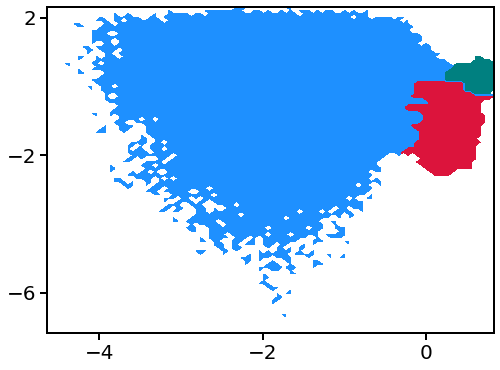

In [18]:
fig,ax = plt.subplots(1, figsize=(8,6))
mplt.plot_state_map(*np.concatenate((tdata)).T, 
                   model.metastable_assignments[np.concatenate((model.dtrajs_active))], 
                   ax=ax, cbar=None, cmap=cmap)
ax.spines[:].set_linewidth(2)
ax.set_xticks([-4,-2,0])
ax.set_yticks([-6,-2,2])
ax.tick_params(labelsize=20, length=7, width=2)
plt.savefig('saved_msm1/statemap.pdf')
plt.show()

In [11]:
mdtrj = [model.metastable_assignments[i] for i in model.dtrajs_active]
mmodel = msm.estimate_markov_model(mdtrj, lag=20)

In [12]:
np.savez('saved_msm1/mdtrj.npz', *mdtrj)

In [7]:
mdtrj = np.load('saved_msm1/mdtrj.npz')
mdtrj = [mdtrj[i] for i in list(mdtrj)]

In [20]:
analyze = ana.analyze_msm_clusters(mdtrj)
analyze.take_data([i[:,1] for i in data])
means, stds, pops = analyze.get_mean()
means, stds, pops

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:09<00:00, 11.51it/s]


(array([0.50589639, 2.82180921, 0.23898427]),
 array([0.15268644, 1.0204374 , 0.03799597]),
 array([0.24080532, 0.27681158, 0.4823831 ]))

In [8]:
analyze = ana.analyze_msm_clusters(mdtrj)
analyze.take_data([i[:,2] for i in data])
means, stds, pops = analyze.get_mean()
means, stds, pops

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:09<00:00, 11.58it/s]


(array([0.81989074, 2.89761065, 0.1106985 ]),
 array([0.13333117, 1.09672854, 0.03944734]),
 array([0.24080532, 0.27681158, 0.4823831 ]))

In [9]:
analyze = ana.analyze_msm_clusters(mdtrj)
analyze.take_data([i[:,3] for i in data])
means, stds, pops = analyze.get_mean()
means, stds, pops

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:08<00:00, 12.02it/s]


(array([49.63189804, 32.16553368,  3.85171965]),
 array([32.77094405, 22.41001387,  2.95680304]),
 array([0.24080532, 0.27681158, 0.4823831 ]))

In [21]:
d1 = np.concatenate((data))
d2 = np.concatenate((mdtrj))
#
distributions = [
    d1[np.where(d2==i)[0]] for i in np.unique(d2)
]

In [22]:
limits = np.min(d1, axis=0), np.max(d1, axis=0)
limits

(array([0.2320778 , 0.012     , 0.0215315 , 0.00044486]),
 array([  4.420024  ,   7.459     ,   8.8447618 , 101.49444486]))

In [23]:
bins = [np.linspace(limits[0][i], limits[1][i], 100) for i in range(4)]
xb = [b[1:] - (b[1]-b[0])/2 for b in bins]

In [24]:
hists = [
    [
        np.histogram(c, bins=bins[a])[0]/len(c)
    for a,c in enumerate(d.T)]
for d in distributions]

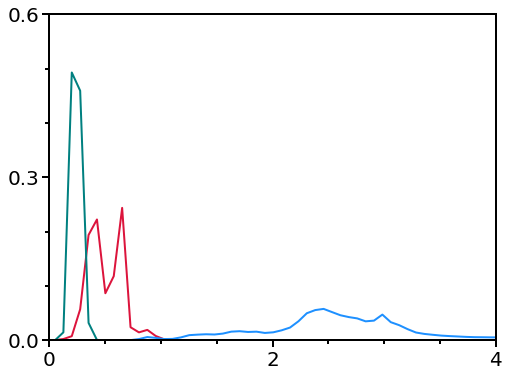

In [26]:
fig,ax=plt.subplots(1, figsize=(8,6))
for a,h in enumerate(hists):
    ax.plot(xb[1], h[1], color=colors[a], lw=2)
ax.set_xlim(0,4)
ax.set_ylim(0,)
ax.set_yticks([0,0.3,0.6])
ax.set_xticks([0,2,4])
ax.xaxis.set_minor_locator(mt.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(mt.ticker.AutoMinorLocator(3))
ax.tick_params(labelsize=20, length=7, width=2)
ax.tick_params(which='minor', length=4, width=2)
ax.spines[:].set_linewidth(2)
plt.savefig('saved_msm1/dists_states.pdf')
plt.show()

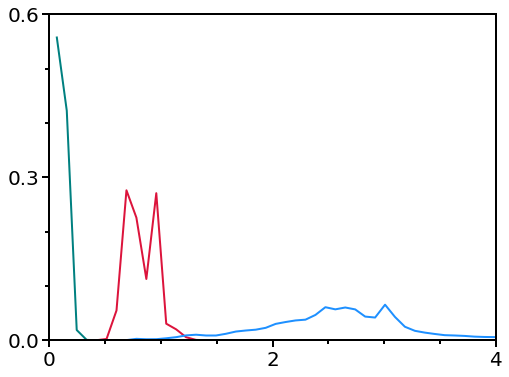

In [27]:
fig,ax=plt.subplots(1, figsize=(8,6))
for a,h in enumerate(hists):
    ax.plot(xb[2], h[2], color=colors[a], lw=2)
ax.set_xlim(0,4)
ax.set_ylim(0,)
ax.set_yticks([0,0.3,0.6])
ax.set_xticks([0,2,4])
ax.xaxis.set_minor_locator(mt.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(mt.ticker.AutoMinorLocator(3))
ax.tick_params(labelsize=20, length=7, width=2)
ax.tick_params(which='minor', length=4, width=2)
ax.spines[:].set_linewidth(2)
plt.savefig('saved_msm1/rmsd_states.pdf')
plt.show()

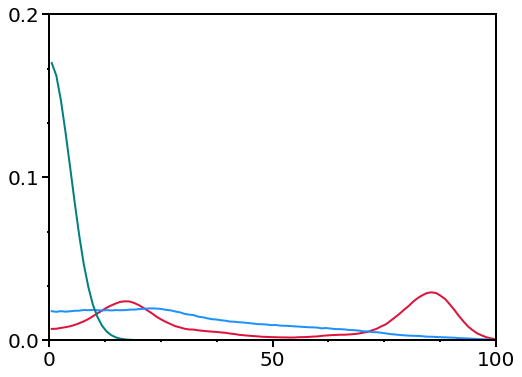

In [28]:
fig,ax=plt.subplots(1, figsize=(8,6))
for a,h in enumerate(hists):
    ax.plot(xb[3], h[3], color=colors[a], lw=2)
ax.set_xlim(0,100)
ax.set_ylim(0,)
ax.set_yticks([0,0.1,0.2])
ax.set_xticks([0,50,100])
ax.xaxis.set_minor_locator(mt.ticker.AutoMinorLocator(4))
ax.yaxis.set_minor_locator(mt.ticker.AutoMinorLocator(3))
ax.tick_params(labelsize=20, length=7, width=2)
ax.tick_params(which='minor', length=2, width=2)
ax.spines[:].set_linewidth(2)
plt.savefig('saved_msm1/angles_states.pdf')
plt.show()

In [109]:
tpt = msm.tpt(model, model.metastable_sets[1], model.metastable_sets[2]) # U --> B
cg, cgflux = tpt.coarse_grain(model.metastable_sets)

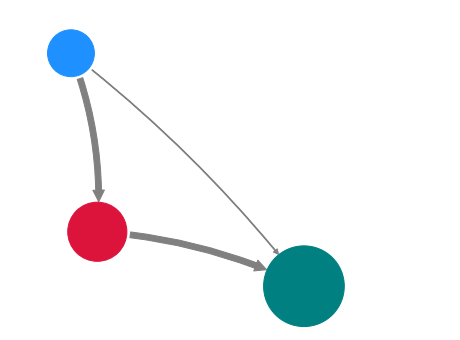

In [115]:
fig,ax = plt.subplots(1, figsize=(8,6))
mplt.plot_flux(cgflux, 
              ax=ax, state_colors=['dodgerblue', 'crimson', 'teal'], 
               arrow_labels=None, show_committor=False, state_labels=None,
               state_sizes = np.array([0.17992304, 0.28652688, 0.53355009]), 
#               pos = np.array([[0,0],[-1,1],[-2,3]])
              )
plt.savefig('saved_msm1/msm.pdf')
plt.show()

In [86]:
nboots = 10
nstates = 3
lag=20
pops = np.zeros((nboots, nstates))
commitors = np.zeros((nboots))
mfpts = np.zeros((nboots, 6)) #U>I, I>B, U>B and reverse
mpairs = [[0,1], [1,0], [1,2], [2,1], [0,2], [2,0]]
paths = []
fluxes = []
transitions = []
#
intuitive = [d[:,1] for d in data]
#
seed = 1234567
np.random.seed(seed)
#
for n in range(nboots):
    indi = list(np.arange(7))+list(7+np.random.permutation(101)[:91])
#     indi = np.random.
    strj = [dtrj[i] for i in indi]
    model = msm.estimate_markov_model(strj, lag=lag)
    model.pcca(nstates)
    #
    mdtrj = [model.metastable_assignments[i] for i in model.dtrajs_active]
    analyze = ana.analyze_msm_clusters(mdtrj)
    analyze.take_data([intuitive[i] for i in indi])
    means, _, _ = analyze.get_mean()
    order = means.argsort()[::-1]
    #
    sets = model.metastable_sets
    pops[n] = [model.pi[sets[a]].sum() for a in order]
    mfpts[n] = [
        model.mfpt(sets[order[a[0]]], sets[order[a[1]]]) * lag*10/1e6 for a in mpairs
    ]
    #
    tpt = msm.tpt(model, sets[order[0]], sets[order[2]])
    cg, cgflux = tpt.coarse_grain(sets)
    commitors[n] = cgflux.committor[1]
    p, pf = cgflux.pathways()
    paths.append(p)
    fluxes.append(pf/np.sum(pf))
    #
    model = msm.estimate_markov_model(mdtrj, lag=20)
    tmt = model.count_matrix_active
    transitions.append([tmt[i][order] for i in order])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 98/98 [00:09<00:00, 10.44it/s]


In [87]:
np.mean(mfpts, axis=0), np.std(mfpts, axis=0)

(array([ 3.53775529,  4.49330771, 18.38842052, 30.13780219, 21.69186905,
        34.61366587]),
 array([0.35548301, 0.95865218, 1.91930002, 5.30844288, 1.78052026,
        5.13539632]))

In [88]:
np.mean(pops, axis=0), np.std(pops, axis=0)

(array([0.28652688, 0.17992304, 0.53355009]),
 array([0.0115659 , 0.00693997, 0.01489406]))

In [89]:
np.mean(commitors), np.std(commitors)

(0.12239733789855223, 0.032631199206504286)

In [93]:
paths

[[array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)],
 [array([0, 1, 2], dtype=int32), array([0, 2], dtype=int32)]]

In [95]:
np.mean(fluxes, axis=0), np.std(fluxes, axis=0)

(array([0.87933717, 0.12066283]), array([0.01033639, 0.01033639]))

In [100]:
np.mean(transitions, axis=0), np.std(transitions, axis=0)

(array([[1.0408670e+06, 6.2111000e+03, 6.0500000e+01],
        [6.4844000e+03, 8.5877850e+05, 4.8810000e+02],
        [4.6500000e+01, 4.1480000e+02, 1.8359811e+06]]),
 array([[2.13726158e+04, 3.15480790e+03, 7.03206940e+00],
        [3.12987179e+03, 2.77781017e+04, 4.98165635e+01],
        [5.37121960e+00, 4.45102235e+01, 1.73779880e+04]]))

In [101]:
np.save('saved_msm1/mfpts.npy', mfpts)
np.save('saved_msm1/pops.npy', pops)
np.save('saved_msm1/commitors.npy', commitors)
np.save('saved_msm1/fluxes.npy', fluxes)
np.save('saved_msm1/transitions.npy', transitions)

### kon

In [104]:
(1 / (10*1e-3 * 21.7 * 1e-6)) / 1e6

4.6082949308755765

$k_{on} = \frac{1}{C \times t_{b}} $ <br><br>
calculation of error <br>
$ \frac{d_{kon}}{k_{on}}  = \sqrt{ (\frac{d_{C}}{C})^2 + (\frac{d_{tb}}{t_{b}})^2 }$ <br>
$ d_{kon} = kon \times \frac{d_{tb}}{t_{b}} $ <br><br>

In [8]:
d_kon = 4.6 * 1.78 / 21.7
d_kon

0.37732718894009215

### extract frames

#### random

In [30]:
def get_trj_index(k, clength):
    for a,i in enumerate(clength):
        if k <= i:
            return [a-1, k-clength[a-1]]

In [23]:
cdtrj = np.concatenate((mdtrj))
indi = [np.where(cdtrj==i)[0] for i in np.unique(cdtrj)]
tlength = [len(i) for i in mdtrj]
clength = np.cumsum([0] + tlength)

In [50]:
np.random.seed(12345678)
nframes = 50
s=0
iframes = indi[s][np.random.permutation(len(indi[s]))][:nframes]
iframes = np.array([get_trj_index(i, clength) for i in iframes])
iframes = {
    i:iframes[:,1][np.where(iframes[:,0]==i)[0]]
    for i in np.unique(iframes[:,0])
}
#
a=1
for trj,frames in iframes.items():
    u = mda.Universe('../0_trjs/bound.pdb',
                    f'../0_trjs/{trajs[trj]}.xtc')
    for f in frames:
        u.trajectory[f]
        u.select_atoms('all').write(f'saved_msm1/frames/s{s}_f{a}.pdb')
        a+=1

/home/jayakrishnak/softwares/anaconda/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1151: UserWarning: Found no information for attr: 'formalcharges' Using default value of '0'
  warnings.warn("Found no information for attr: '{}'"
/home/jayakrishnak/softwares/anaconda/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1198: UserWarning: Found missing chainIDs. Corresponding atoms will use value of 'X'
  warnings.warn("Found missing chainIDs."


In [51]:
np.random.seed(12345678)
nframes = 50
s=1
iframes = indi[s][np.random.permutation(len(indi[s]))][:nframes]
iframes = np.array([get_trj_index(i, clength) for i in iframes])
iframes = {
    i:iframes[:,1][np.where(iframes[:,0]==i)[0]]
    for i in np.unique(iframes[:,0])
}
#
a=1
for trj,frames in iframes.items():
    u = mda.Universe('../0_trjs/bound.pdb',
                    f'../0_trjs/{trajs[trj]}.xtc')
    for f in frames:
        u.trajectory[f]
        u.select_atoms('all').write(f'saved_msm1/frames/s{s}_f{a}.pdb')
        a+=1

In [52]:
np.random.seed(12345678)
nframes = 50
s=2
iframes = indi[s][np.random.permutation(len(indi[s]))][:nframes]
iframes = np.array([get_trj_index(i, clength) for i in iframes])
iframes = {
    i:iframes[:,1][np.where(iframes[:,0]==i)[0]]
    for i in np.unique(iframes[:,0])
}
#
a=1
for trj,frames in iframes.items():
    u = mda.Universe('../0_trjs/bound.pdb',
                    f'../0_trjs/{trajs[trj]}.xtc')
    for f in frames:
        u.trajectory[f]
        u.select_atoms('all').write(f'saved_msm1/frames/s{s}_f{a}.pdb')
        a+=1

### pr-lig contact maps of states

In [53]:
contacts = np.load('../6_pr-lig-contacts/0_data/out.npz')
contacts = [contacts[i] for i in list(contacts)]

In [63]:
contacts = np.concatenate((contacts))

In [64]:
contacts.shape

(3851302, 228)

In [82]:
cutoff = 0.51
#
cint = np.sum(
    contacts[indi[0]] <= cutoff, axis=0
) / len(indi[0])
#
cbound = np.sum(
    contacts[indi[2]] <= cutoff, axis=0
) / len(indi[2])

<BarContainer object of 228 artists>

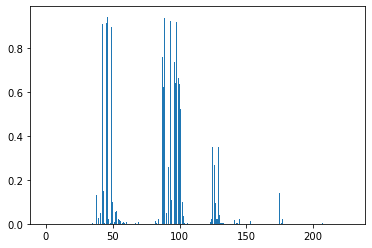

In [84]:
plt.bar(range(228), cint)

<BarContainer object of 228 artists>

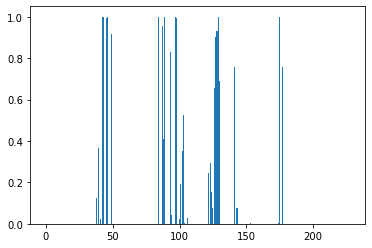

In [85]:
plt.bar(range(228), cbound)

In [123]:
diff = cint - cbound

In [124]:
diff.min()

-0.9784332523089098

In [125]:
diff.max()

0.7383996607528246

In [90]:
np.where(diff<-0.5)[0] + 9

array([ 52,  93, 136, 137, 138, 139, 150, 184, 186])

In [91]:
np.where(diff>0.5)[0] + 9

array([105, 108, 109])

In [94]:
np.where(cint>0.9)[0]+9

array([ 51,  54,  55,  98, 102, 107])

In [95]:
np.where(cbound>0.9)[0]+9

array([ 51,  52,  54,  55,  58,  93,  96,  98, 106, 107, 136, 137, 138,
       184])

In [99]:
ofile = open('saved_msm1/contacts/cint.pdb', 'w')
for l in open('../0_trjs/bound.pdb', 'r'):
    i = l.strip().split()
    if ('ATOM' in i[0]) and ('GDM' not in l):
        resid = int(i[4])
        ofile.write(l[:62] + f'{np.round(cint[resid-9], 2)}' + l[66:])
    else:
        ofile.write(l)
ofile.close()

In [100]:
ofile = open('saved_msm1/contacts/cbound.pdb', 'w')
for l in open('../0_trjs/bound.pdb', 'r'):
    i = l.strip().split()
    if ('ATOM' in i[0]) and ('GDM' not in l):
        resid = int(i[4])
        ofile.write(l[:62] + f'{np.round(cbound[resid-9], 2)}' + l[66:])
    else:
        ofile.write(l)
ofile.close()

In [126]:
ofile = open('saved_msm1/contacts/cdiff.pdb', 'w')
for l in open('../0_trjs/bound.pdb', 'r'):
    i = l.strip().split()
    if ('ATOM' in i[0]) and ('GDM' not in l):
        resid = int(i[4])
        ofile.write(l[:61] + f'{diff[resid-9]:5.2f}' + l[66:])
    else:
        ofile.write(l)
ofile.close()

### re-calculated pops

$\Delta G = - k_{\beta}T ln (\frac{P_B}{P_U})$ <br>
$\Delta G = k_{\beta}T ln (\frac{C \dot t_B}{t_U})  $ <br>
$ \frac{P_U}{P_B} = \frac{C \times t_B}{t_U} $

In [18]:
tb = 21.69e-6
tu = 11.44 
C = 10e-2

In [19]:
pop_frac = C*tb / tu
pop_frac

1.8959790209790212e-07

$ P_B = P_U \times 1.9e+7$

$ \frac{P_B}{P_B + P_U} \times 100 = \frac{1.9e+7}{1.9e+7 + 1} \times 100 $

In [21]:
(1.89e7 / (1.89e7+1))*100

99.99999470899499

In [27]:
f'{100 - (1.89e7 / (1.89e7+1))*100:8.6f}'

'0.000005'

binding energy with newer populations

In [28]:
-0.5922 * np.log(99.999995 / 0.000005)

-9.955617975215114